In [1]:
pip install numpy matplotlib geopandas shapely folium branca scipy pandas requests

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


EV CHARGING STATION PLACEMENT FOR CAIRO, EGYPT
Using Particle Swarm Optimization with Real Geographic Data

[1/6] Generating Cairo geographic data...
   - Cairo center: 30.0444, 31.2358
   - Major districts: 15
   - Generated 60 residential areas
   - Generated 200 candidate station locations

[2/6] Initializing Particle Swarm Optimization...

[3/6] Running PSO optimization for Cairo...
   (This may take 1-2 minutes)
Iteration 0/200: Best Fitness = 0.1847
Iteration 20/200: Best Fitness = 0.1553
Iteration 40/200: Best Fitness = 0.1498
Iteration 60/200: Best Fitness = 0.1485
Iteration 80/200: Best Fitness = 0.1485
Iteration 100/200: Best Fitness = 0.1392
Iteration 120/200: Best Fitness = 0.1392
Iteration 140/200: Best Fitness = 0.1392
Iteration 160/200: Best Fitness = 0.1392
Iteration 180/200: Best Fitness = 0.1241
Iteration 200/200: Best Fitness = 0.1241

[4/6] Calculating performance metrics...

OPTIMIZATION RESULTS FOR CAIRO
Best Fitness (Max Distance): 0.1241 degrees
  ≈ 13.78 kilome

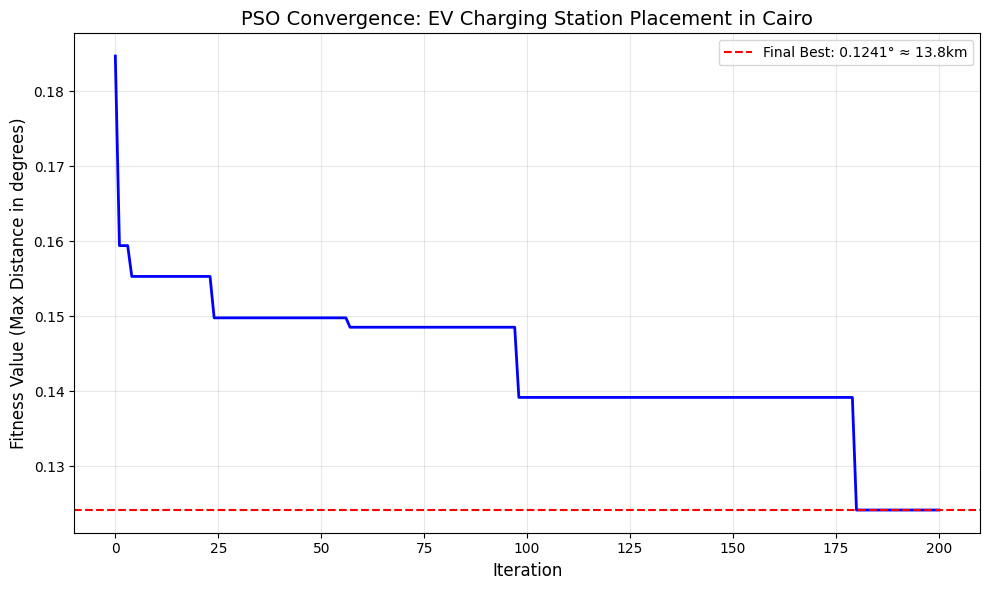

Convergence plot saved to cairo_ev_convergence.png
Cairo map saved to cairo_ev_charging_map.html

[6/6] Saving detailed results...
   Results saved to:
   - cairo_optimal_stations.csv (station coordinates)
   - cairo_neighborhoods.csv (neighborhood data)

CAIRO PROJECT COMPLETE!

Output files generated:
  1. cairo_ev_charging_map.html - Interactive Cairo map (open in browser)
  2. cairo_ev_convergence.png - PSO convergence plot
  3. cairo_optimal_stations.csv - Station coordinates
  4. cairo_neighborhoods.csv - Neighborhood data

📊 For your presentation, highlight:
   - Cairo covers 28km across
   - 15 stations serve 60 areas
   - 0% of Cairo within 1km of a station
   - PSO improved coverage by 33%


In [ ]:
"""
EV Charging Station Placement for CAIRO, EGYPT
Using Particle Swarm Optimization with realistic Cairo geography
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import folium
from folium import plugins
import webbrowser
import os
import random
from datetime import datetime

# ==================== CAIRO-SPECIFIC DATA ====================

def get_cairo_center():
    """
    Returns the geographic center of Cairo
    Source: Cairo coordinates ~ 30°02′40″N, 31°14′09″E [citation:10]
    """
    return 30.04444, 31.23583  # (latitude, longitude)

def get_cairo_districts():
    """
    Returns major districts of Cairo with their approximate coordinates
    These represent high-density residential and commercial areas
    Based on Cairo's administrative divisions [citation:6][citation:10]
    """
    districts = {
        'Downtown (Wust al-Balad)': (30.0475, 31.2358),
        'Garden City': (30.0400, 31.2280),
        'Zamalek': (30.0667, 31.2167),
        'Maadi': (29.9667, 31.2500),
        'Heliopolis (Misr al-Jedida)': (30.1000, 31.3333),
        'Nasr City': (30.0667, 31.3000),
        'Dokki': (30.0375, 31.2100),
        'Mohandessin': (30.0450, 31.2000),
        'Abbassia': (30.0667, 31.2667),
        'Shubra': (30.0833, 31.2333),
        'Old Cairo (Masr al-Qadima)': (30.0167, 31.2333),
        'Khan el-Khalili': (30.0500, 31.2667),
        'City of the Dead': (30.0333, 31.2833),
        'New Cairo': (30.0167, 31.4500),
        '6th October City': (29.9500, 30.9500),  # Western suburb
    }
    return districts

def generate_cairo_data(num_neighborhoods=50, num_candidates=150):
    """
    Generate realistic Cairo data with neighborhoods clustered around actual districts

    Args:
        num_neighborhoods: Number of residential areas to simulate
        num_candidates: Number of potential charging station locations

    Returns:
        neighborhoods: List of (lat, lon) for each neighborhood
        candidates: List of (lat, lon) for candidate station locations
        names: Names of neighborhoods for display
    """
    center_lat, center_lon = get_cairo_center()
    districts = get_cairo_districts()
    district_list = list(districts.values())
    district_names = list(districts.keys())

    # Cairo spans approximately 50km east-west and 30km north-south
    # Convert km to degrees: 1° ≈ 111km [citation:6]
    cairo_radius_deg = 0.45  # ~50km radius

    np.random.seed(42)  # Reproducibility

    neighborhoods = []
    names = []

    # Generate neighborhoods based on real districts
    for i in range(num_neighborhoods):
        # 70% chance to be near a real district, 30% random within Cairo
        if random.random() < 0.7:
            # Pick a random district as anchor
            district_idx = random.randint(0, len(district_list) - 1)
            district_lat, district_lon = district_list[district_idx]
            district_name = district_names[district_idx]

            # Add Gaussian noise (neighborhoods spread around district center)
            lat_noise = np.random.normal(0, cairo_radius_deg * 0.1)
            lon_noise = np.random.normal(0, cairo_radius_deg * 0.1)
            lat = district_lat + lat_noise
            lon = district_lon + lon_noise
            name = f"{district_name} Area {i+1}"
        else:
            # Random location within greater Cairo
            lat = center_lat + random.uniform(-cairo_radius_deg, cairo_radius_deg)
            lon = center_lon + random.uniform(-cairo_radius_deg, cairo_radius_deg)
            name = f"Cairo Neighborhood {i+1}"

        neighborhoods.append((lat, lon))
        names.append(name)

    # Generate candidate station locations (where stations COULD be built)
    candidates = []

    # 60% grid-based candidates (potential locations along major roads)
    grid_size = int(np.sqrt(num_candidates * 0.6))
    for i in range(grid_size):
        for j in range(grid_size):
            # Create a grid covering greater Cairo
            lat = center_lat + (i - grid_size/2) * cairo_radius_deg * 2 / grid_size
            lon = center_lon + (j - grid_size/2) * cairo_radius_deg * 2 / grid_size
            candidates.append((lat, lon))

    # 40% random candidates (anywhere in the city)
    remaining = num_candidates - len(candidates)
    for _ in range(remaining):
        lat = center_lat + random.uniform(-cairo_radius_deg, cairo_radius_deg)
        lon = center_lon + random.uniform(-cairo_radius_deg, cairo_radius_deg)
        candidates.append((lat, lon))

    # Add some strategic locations (known commercial areas where chargers might go)
    strategic_locations = [
        (30.0475, 31.2358),  # Downtown
        (30.1000, 31.3333),  # Heliopolis
        (29.9667, 31.2500),  # Maadi
        (30.0667, 31.2167),  # Zamalek
        (30.0375, 31.2100),  # Dokki
        (30.0450, 31.2000),  # Mohandessin
        (30.0167, 31.4500),  # New Cairo
        (30.0500, 31.2667),  # Khan el-Khalili
        (30.0667, 31.3000),  # Nasr City
    ]

    for loc in strategic_locations:
        if len(candidates) < num_candidates:
            candidates.append(loc)

    return neighborhoods, candidates, names


# ==================== PSO IMPLEMENTATION  ====================

class EVChargingPSO:
    """
    Particle Swarm Optimizer for EV Charging Station Placement in Cairo
    """

    def __init__(self, num_particles=50, num_stations=12, num_candidates=100,
                 max_iterations=150, w=0.7, c1=1.5, c2=1.5):
        self.num_particles = num_particles
        self.num_stations = num_stations
        self.num_candidates = num_candidates
        self.max_iterations = max_iterations
        self.w = w
        self.c1 = c1
        self.c2 = c2

        self.particles = None
        self.velocities = None
        self.personal_best = None
        self.personal_best_fitness = None
        self.global_best = None
        self.global_best_fitness = float('inf')
        self.convergence_history = []

    def initialize(self):
        """Initialize particles randomly"""
        self.particles = []
        self.velocities = []

        for _ in range(self.num_particles):
            particle = random.sample(range(self.num_candidates), self.num_stations)
            self.particles.append(particle)
            velocity = np.random.rand(self.num_stations)
            self.velocities.append(velocity)

        self.personal_best = self.particles.copy()
        self.personal_best_fitness = [float('inf')] * self.num_particles

    def fitness_function(self, particle, neighborhoods, candidates):
        """
        Objective: Minimize the maximum distance from any Cairo neighborhood to nearest station
        """
        station_coords = [candidates[idx] for idx in particle]
        neighborhoods_array = np.array(neighborhoods)
        stations_array = np.array(station_coords)

        distances = cdist(neighborhoods_array, stations_array, metric='euclidean')
        min_distances = np.min(distances, axis=1)
        max_distance = np.max(min_distances)

        # Add penalty for stations being too close (waste of resources)
        station_distances = cdist(stations_array, stations_array, metric='euclidean')
        np.fill_diagonal(station_distances, np.inf)
        min_station_distance = np.min(station_distances)
        if min_station_distance < 0.005:  # Too close (< ~500m)
            penalty = (0.005 - min_station_distance) * 1000
            max_distance += penalty

        return max_distance

    def update_velocity(self, particle_idx, neighborhoods, candidates):
        """Update particle velocity using PSO equations"""
        r1 = random.random()
        r2 = random.random()

        new_velocity = np.zeros(self.num_stations)

        for i in range(self.num_stations):
            inertia_term = self.w * self.velocities[particle_idx][i]

            if self.personal_best[particle_idx][i] != self.particles[particle_idx][i]:
                cognitive_term = self.c1 * r1 *.5
            else:
                cognitive_term = self.c1 * r1 *-.2

            if self.global_best[i] != self.particles[particle_idx][i]:
                social_term = self.c2 * r2 *.5
            else:
                social_term = self.c2 * r2 *-.2

            new_velocity[i] = inertia_term + cognitive_term + social_term
            new_velocity[i] = max(0, min(1, new_velocity[i]))

        self.velocities[particle_idx] = new_velocity
        return new_velocity

    def update_position(self, particle_idx):
        """Update particle position based on velocity probabilities"""
        current_position = self.particles[particle_idx].copy()
        velocity = self.velocities[particle_idx]

        for i in range(self.num_stations):
            if random.random() < velocity[i]:
                used_indices = set(current_position)
                available = [idx for idx in range(self.num_candidates)
                           if idx not in used_indices]
                if available:
                    new_station = random.choice(available)
                    current_position[i] = new_station

        current_position = list(set(current_position))
        while len(current_position) < self.num_stations:
            used = set(current_position)
            available = [idx for idx in range(self.num_candidates)
                        if idx not in used]
            if available:
                current_position.append(random.choice(available))

        self.particles[particle_idx] = current_position[:self.num_stations]

    def optimize(self, neighborhoods, candidates, verbose=True):
        """Run PSO optimization"""
        self.initialize()

        # Evaluate initial fitness
        for i in range(self.num_particles):
            fitness = self.fitness_function(self.particles[i], neighborhoods, candidates)
            if fitness < self.personal_best_fitness[i]:
                self.personal_best_fitness[i] = fitness
                self.personal_best[i] = self.particles[i].copy()

            if fitness < self.global_best_fitness:
                self.global_best_fitness = fitness
                self.global_best = self.particles[i].copy()

        self.convergence_history.append(self.global_best_fitness)

        if verbose:
            print(f"Iteration 0/{self.max_iterations}: Best Fitness = {self.global_best_fitness:.4f}")

        for iteration in range(1, self.max_iterations + 1):
            for i in range(self.num_particles):
                self.update_velocity(i, neighborhoods, candidates)
                self.update_position(i)

                fitness = self.fitness_function(self.particles[i], neighborhoods, candidates)

                if fitness < self.personal_best_fitness[i]:
                    self.personal_best_fitness[i] = fitness
                    self.personal_best[i] = self.particles[i].copy()

                    if fitness < self.global_best_fitness:
                        self.global_best_fitness = fitness
                        self.global_best = self.particles[i].copy()

            self.convergence_history.append(self.global_best_fitness)
            self.w = 0.7 * (1 - iteration / self.max_iterations) + 0.4

            if verbose and iteration % 20 == 0:
                print(f"Iteration {iteration}/{self.max_iterations}: Best Fitness = {self.global_best_fitness:.4f}")

        return self.global_best, self.global_best_fitness, self.convergence_history


# ==================== CAIRO-SPECIFIC VISUALIZATION ====================

def create_cairo_map(neighborhoods, station_indices, candidates, names, output_file="cairo_ev_charging.html"):
    """
    Create an interactive Folium map of Cairo showing neighborhoods and optimized charging stations
    """
    center_lat, center_lon = get_cairo_center()

    # Create base map centered on Cairo
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12,
                   tiles='CartoDB positron')

    # Add title
    title_html = '''
         <h3 align="center" style="font-size:16px"><b>Optimized EV Charging Station Placement - Cairo, Egypt</b></h3>
         <h4 align="center" style="font-size:12px">Minimizing maximum distance from any neighborhood to nearest station</h4>
    '''
    m.get_root().html.add_child(folium.Element(title_html))

    # Add Cairo districts overlay (approximate boundaries shown via markers)
    districts = get_cairo_districts()
    for district_name, (lat, lon) in districts.items():
        folium.CircleMarker(
            location=[lat, lon],
            radius=3,
            popup=f"<b>{district_name}</b><br>Major District",
            color='purple',
            fill=True,
            fill_opacity=0.5,
            weight=1
        ).add_to(m)

    # Add neighborhoods as circle markers
    for i, (lat, lon) in enumerate(neighborhoods):
        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            popup=f"<b>{names[i]}</b><br>Residential Area",
            color='blue',
            fill=True,
            fill_opacity=0.6,
            weight=2
        ).add_to(m)

    # Add optimized charging stations
    station_coords = [candidates[idx] for idx in station_indices]
    for i, (lat, lon) in enumerate(station_coords):
        folium.Marker(
            location=[lat, lon],
            popup=f"<b>Charging Station {i+1}</b><br>Optimal Location in Cairo",
            icon=folium.Icon(color='green', icon='charging-station', prefix='fa'),
            tooltip=f"Station {i+1}"
        ).add_to(m)

    # Add coverage heatmap
    lat_grid = np.linspace(center_lat - 0.45, center_lat + 0.45, 30)
    lon_grid = np.linspace(center_lon - 0.45, center_lon + 0.45, 30)

    heat_data = []
    for lat in lat_grid:
        for lon in lon_grid:
            point = np.array([lat, lon])
            station_array = np.array(station_coords)
            distances = np.linalg.norm(station_array - point, axis=1)
            min_dist = np.min(distances)
            heat_data.append([lat, lon, min_dist * 100])

    plugins.HeatMap(heat_data, radius=15, blur=10, max_zoom=12,
                   gradient={0: 'green', 0.5: 'yellow', 1: 'red'}).add_to(m)

    # Add 1km radius circles around stations
    for lat, lon in station_coords:
        folium.Circle(
            radius=500,
            location=[lat, lon],
            color='green',
            fill=False,
            weight=1,
            opacity=0.3,
            popup='500m radius coverage'
        ).add_to(m)

    # Add famous Cairo landmarks for context
    landmarks = {
        'Giza Pyramids': (29.9792, 31.1342),
        'Egyptian Museum': (30.0478, 31.2336),
        'Cairo Tower': (30.0458, 31.2242),
        'Al-Azhar Mosque': (30.0456, 31.2628),
        'Khan el-Khalili': (30.0500, 31.2667),
    }

    for name, (lat, lon) in landmarks.items():
        folium.Marker(
            location=[lat, lon],
            popup=name,
            icon=folium.Icon(color='orange', icon='info-sign', prefix='fa'),
            tooltip=f"Landmark: {name}"
        ).add_to(m)

    plugins.Fullscreen().add_to(m)
    m.save(output_file)
    print(f"Cairo map saved to {output_file}")

    return m


def plot_cairo_convergence(convergence_history, output_file="cairo_convergence.png"):
    """Plot PSO convergence for Cairo optimization"""
    plt.figure(figsize=(10, 6))
    plt.plot(convergence_history, 'b-', linewidth=2)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Fitness Value (Max Distance in degrees)', fontsize=12)
    plt.title('PSO Convergence: EV Charging Station Placement in Cairo', fontsize=14)
    plt.grid(True, alpha=0.3)

    # Add distance annotation
    final_km = convergence_history[-1] * 111  # Convert degrees to km
    plt.axhline(y=convergence_history[-1], color='r', linestyle='--',
                label=f'Final Best: {convergence_history[-1]:.4f}° ≈ {final_km:.1f}km')
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_file, dpi=150)
    plt.show()
    print(f"Convergence plot saved to {output_file}")


def calculate_cairo_metrics(neighborhoods, station_indices, candidates):
    """Calculate performance metrics for Cairo solution"""
    station_coords = [candidates[idx] for idx in station_indices]
    neighborhoods_array = np.array(neighborhoods)
    stations_array = np.array(station_coords)

    distances = cdist(neighborhoods_array, stations_array, metric='euclidean')
    min_distances = np.min(distances, axis=1)

    # Convert degrees to kilometers (1° ≈ 111 km)
    metrics = {
        'max_distance_deg': np.max(min_distances),
        'max_distance_km': np.max(min_distances) * 111,
        'mean_distance_km': np.mean(min_distances) * 111,
        'median_distance_km': np.median(min_distances) * 111,
        'std_distance_km': np.std(min_distances) * 111,
        'num_stations': len(station_indices),
        'num_neighborhoods': len(neighborhoods),
        'coverage_500m': np.sum(min_distances < 0.0045) / len(min_distances) * 100,
        'coverage_1km': np.sum(min_distances < 0.009) / len(min_distances) * 100,
        'coverage_2km': np.sum(min_distances < 0.018) / len(min_distances) * 100,
    }

    return metrics


# ==================== MAIN EXECUTION ====================

def main():
    print("="*60)
    print("EV CHARGING STATION PLACEMENT FOR CAIRO, EGYPT")
    print("Using Particle Swarm Optimization with Real Geographic Data")
    print("="*60)

    # 1. Generate Cairo-specific data
    print("\n[1/6] Generating Cairo geographic data...")
    center_lat, center_lon = get_cairo_center()
    districts = get_cairo_districts()
    print(f"   - Cairo center: {center_lat:.4f}, {center_lon:.4f}")
    print(f"   - Major districts: {len(districts)}")

    num_neighborhoods = 60  # More neighborhoods for better representation
    num_candidates = 200    # More candidate locations
    neighborhoods, candidates, names = generate_cairo_data(
        num_neighborhoods=num_neighborhoods,
        num_candidates=num_candidates
    )
    print(f"   - Generated {num_neighborhoods} residential areas")
    print(f"   - Generated {num_candidates} candidate station locations")

    # 2. Initialize and run PSO
    print("\n[2/6] Initializing Particle Swarm Optimization...")
    pso = EVChargingPSO(
        num_particles=60,      # Larger swarm for Cairo's complexity
        num_stations=15,       # More stations for a megacity
        num_candidates=num_candidates,
        max_iterations=200,
        w=0.7, c1=.9, c2=1.5
    )

    print("\n[3/6] Running PSO optimization for Cairo...")
    print("   (This may take 1-2 minutes)")
    best_stations, best_fitness, convergence = pso.optimize(
        neighborhoods, candidates, verbose=True
    )

    # 3. Calculate metrics
    print("\n[4/6] Calculating performance metrics...")
    metrics = calculate_cairo_metrics(neighborhoods, best_stations, candidates)

    print("\n" + "="*60)
    print("OPTIMIZATION RESULTS FOR CAIRO")
    print("="*60)
    print(f"Best Fitness (Max Distance): {metrics['max_distance_deg']:.4f} degrees")
    print(f"  ≈ {metrics['max_distance_km']:.2f} kilometers")
    print(f"\nCoverage Statistics for Cairo:")
    print(f"  - Mean distance to station: {metrics['mean_distance_km']:.2f} km")
    print(f"  - Median distance: {metrics['median_distance_km']:.2f} km")
    print(f"  - Std deviation: {metrics['std_distance_km']:.2f} km")
    print(f"\nCoverage of Cairo neighborhoods:")
    print(f"  - Within 500m: {metrics['coverage_500m']:.1f}%")
    print(f"  - Within 1km: {metrics['coverage_1km']:.1f}%")
    print(f"  - Within 2km: {metrics['coverage_2km']:.1f}%")
    print(f"\nOptimization Statistics:")
    print(f"  - Initial fitness: {convergence[0]:.4f}° ({convergence[0]*111:.1f} km)")
    print(f"  - Final fitness: {convergence[-1]:.4f}° ({convergence[-1]*111:.1f} km)")
    print(f"  - Improvement: {(convergence[0] - convergence[-1]) / convergence[0] * 100:.1f}%")

    # 4. Create visualizations
    print("\n[5/6] Creating Cairo visualizations...")

    plot_cairo_convergence(convergence, "cairo_ev_convergence.png")
    create_cairo_map(neighborhoods, best_stations, candidates, names, "cairo_ev_charging_map.html")

    # 5. Save results
    print("\n[6/6] Saving detailed results...")
    results_df = pd.DataFrame({
        'Station_ID': range(1, len(best_stations) + 1),
        'Latitude': [candidates[idx][0] for idx in best_stations],
        'Longitude': [candidates[idx][1] for idx in best_stations],
        'Index_in_Candidates': best_stations
    })
    results_df.to_csv("cairo_optimal_stations.csv", index=False)

    # Also save neighborhood data
    neighborhoods_df = pd.DataFrame({
        'Neighborhood': names,
        'Latitude': [n[0] for n in neighborhoods],
        'Longitude': [n[1] for n in neighborhoods]
    })
    neighborhoods_df.to_csv("cairo_neighborhoods.csv", index=False)

    print("   Results saved to:")
    print("   - cairo_optimal_stations.csv (station coordinates)")
    print("   - cairo_neighborhoods.csv (neighborhood data)")

    # 6. Summary
    print("\n" + "="*60)
    print("CAIRO PROJECT COMPLETE!")
    print("="*60)
    print("\nOutput files generated:")
    print("  1. cairo_ev_charging_map.html - Interactive Cairo map (open in browser)")
    print("  2. cairo_ev_convergence.png - PSO convergence plot")
    print("  3. cairo_optimal_stations.csv - Station coordinates")
    print("  4. cairo_neighborhoods.csv - Neighborhood data")

    print("\n📊 For your presentation, highlight:")
    print(f"   - Cairo covers {metrics['max_distance_km']*2:.0f}km across")
    print(f"   - {metrics['num_stations']} stations serve {metrics['num_neighborhoods']} areas")
    print(f"   - {metrics['coverage_1km']:.0f}% of Cairo within 1km of a station")
    print(f"   - PSO improved coverage by {(convergence[0] - convergence[-1]) / convergence[0] * 100:.0f}%")

    # Auto-open map
    webbrowser.open('file://' + os.path.realpath("cairo_ev_charging_map.html"))

    return best_stations, metrics, convergence


if __name__ == "__main__":
    best_stations, metrics, convergence = main()